In [60]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)

Pandas: 2.3.3
NumPy: 2.5.1
Matplotlib: 3.11.1


In [61]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib
import warnings
warnings.filterwarnings('ignore')

In [62]:
# Load Data

df       = pd.read_csv('train-test.csv')
df_prod  = pd.read_csv('validation.csv')
template = pd.read_csv('validation-predictions-template.csv')

print(f" Train data loaded:    {df.shape[0]:,} rows x {df.shape[1]} cols")
print(f" Test data loaded:     {df_prod.shape[0]:,} rows x {df_prod.shape[1]} cols")
print(f" Template loaded:      {template.shape[0]:,} load_ids")

# Verify template matches validation load_ids
assert set(template['load_id']) == set(df_prod['load_id']), "load_id mismatch!"
print(f" Template load_ids match validation.csv exactly")

 Train data loaded:    48,000 rows x 14 cols
 Test data loaded:     12,000 rows x 13 cols
 Template loaded:      12,000 load_ids
 Template load_ids match validation.csv exactly


In [63]:
# Data Cleaning

# Fix weight sign-flip errors
# (Validated: abs(negative weights) matches positive population distribution)
negative_count = (df['weight'] < 0).sum()
df['weight'] = df['weight'].abs()
print(f"Fixed {negative_count} weight sign-flip errors")

Fixed 292 weight sign-flip errors


In [64]:
# Verify no duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


In [65]:
# Feature Engineering

def engineer_features(data):
    data = data.copy()

    # Fix weight sign-flips
    data['weight'] = data['weight'].abs()

    # Extract time features from date
    # (Seasonal swing of 16% in rate_per_mile found during EDA)
    data['date']        = pd.to_datetime(data['date'])
    data['month']       = data['date'].dt.month          # 1-12: seasonal
    data['week']        = data['date'].dt.isocalendar().week.astype(int)  # 1-52
    data['day_of_week'] = data['date'].dt.dayofweek      # 0=Monday, 6=Sunday
    data['quarter']     = data['date'].dt.quarter         # 1-4

    return data


# Apply to both training and production data
df      = engineer_features(df)
df_prod = engineer_features(df_prod)

print(f"Engineered features: month, week, day_of_week, quarter")
print(f"month range:       {df['month'].min()} - {df['month'].max()}")
print(f"week range:        {df['week'].min()} - {df['week'].max()}")
print(f"day_of_week range: {df['day_of_week'].min()} - {df['day_of_week'].max()}")
print(f"quarter range:     {df['quarter'].min()} - {df['quarter'].max()}")

Engineered features: month, week, day_of_week, quarter
month range:       1 - 10
week range:        1 - 44
day_of_week range: 0 - 6
quarter range:     1 - 4


In [66]:
# Separate features (X), Target (Y) and Tracking ID

# Features to use in the model
# Excluded: load_id (identifier), pickup/delivery text (redundant with distance),
#           lat/lon (tested — no added value over distance), date (engineered above)
# Target:   posted_rate (what we predict)

FEATURES    = [
    'distance',      # strongest predictor (0.91 correlation with target)
    'weight',        # load weight
    'market_index',  # market condition signal
    'quote_signal',  # pricing signal
    'equipment',     # truck type (Dry Van, Reefer, Flatbed)
    'month',         # seasonal pattern
    'week',          # sub-seasonal pattern
    'day_of_week',   # weekly pattern
    'quarter'        # quarterly trend
]

In [67]:
IMPUTE_COLS = ['weight', 'market_index']  # columns with missing values
TARGET      = 'posted_rate'

In [68]:
y        = df[TARGET]
X        = df[FEATURES].copy()
load_ids = df['load_id']

print(f"Features (X) shape:  {X.shape}")
print(f"Target (y) shape:    {y.shape}")
print(f"load_ids shape:      {load_ids.shape}")
print(f"\nFeatures selected ({len(FEATURES)}):")
for i, feat in enumerate(FEATURES, 1):
    print(f"  {i}. {feat}")

Features (X) shape:  (48000, 9)
Target (y) shape:    (48000,)
load_ids shape:      (48000,)

Features selected (9):
  1. distance
  2. weight
  3. market_index
  4. quote_signal
  5. equipment
  6. month
  7. week
  8. day_of_week
  9. quarter


In [69]:
# Train / Test Split

X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X, y, load_ids,
    test_size=0.2,     # 20% goes to test set
    random_state=42    # reproducible split every time
)

print(f"Split complete (80/20, random_state=42)")
print(f"\n  X_train:  {X_train.shape}  ← Model LEARNS from this")
print(f"  X_test:   {X_test.shape}   ← Model is EVALUATED on this")
print(f"  y_train:  {y_train.shape}")
print(f"  y_test:   {y_test.shape}")
print(f"  id_train: {id_train.shape}")
print(f"  id_test:  {id_test.shape}")

Split complete (80/20, random_state=42)

  X_train:  (38400, 9)  ← Model LEARNS from this
  X_test:   (9600, 9)   ← Model is EVALUATED on this
  y_train:  (38400,)
  y_test:   (9600,)
  id_train: (38400,)
  id_test:  (9600,)


In [70]:
# Verify zero overlap between train and test
overlap = len(set(id_train) & set(id_test))
print(f"\n  Overlap check: {overlap} loads in both sets "
      f"({'No data leakage!' if overlap == 0 else 'PROBLEM!'})")


  Overlap check: 0 loads in both sets (No data leakage!)


In [71]:
# Data Preprocessing 

# Median Imputation
# Better than dropping: keeps all rows, needed for production where
# we cannot drop any of the 12,000 required predictions
imputer = SimpleImputer(strategy='median')
X_train[IMPUTE_COLS] = imputer.fit_transform(X_train[IMPUTE_COLS])  # fit + transform
X_test[IMPUTE_COLS]  = imputer.transform(X_test[IMPUTE_COLS])       # transform only!

print(f"Imputer fit on training data only")
print(f"Medians learned:")
print(f"weight:       {imputer.statistics_[0]:.0f}")
print(f"market_index: {imputer.statistics_[1]:.4f}")

Imputer fit on training data only
Medians learned:
weight:       31485
market_index: 1.0552


In [72]:
# Label Encoding for equipment column
# (Convert text categories to numbers — ML models require numeric input)
le = LabelEncoder()
X_train['equipment'] = le.fit_transform(X_train['equipment'])  # fit + transform
X_test['equipment']  = le.transform(X_test['equipment'])       # transform only!

print(f"\n Encoder fit on training data only")
print(f" Equipment mapping: {dict(zip(le.classes_, range(len(le.classes_))))}")
print(f"  Dry Van = 0")
print(f"  Flatbed = 1")
print(f"  Reefer  = 2")


 Encoder fit on training data only
 Equipment mapping: {'Dry Van': 0, 'Flatbed': 1, 'Reefer': 2}
  Dry Van = 0
  Flatbed = 1
  Reefer  = 2


In [73]:
# Verify no missing values remain
assert X_train.isnull().sum().sum() == 0, "Missing values in X_train!"
assert X_test.isnull().sum().sum() == 0, "Missing values in X_test!"
print(f"\n Zero missing values in X_train and X_test")


 Zero missing values in X_train and X_test


In [74]:
# Imputation
X_imp = X.copy()
le_imp = LabelEncoder()
X_imp['equipment'] = le_imp.fit_transform(X_imp['equipment'])

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_imp, y, test_size=0.2, random_state=42
)
imp_proof = SimpleImputer(strategy='median')
X_train_i[IMPUTE_COLS] = imp_proof.fit_transform(X_train_i[IMPUTE_COLS])
X_test_i[IMPUTE_COLS]  = imp_proof.transform(X_test_i[IMPUTE_COLS])

model_imp = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_imp.fit(X_train_i, y_train_i)
mae_imp = mean_absolute_error(y_test_i, model_imp.predict(X_test_i))
r2_imp  = r2_score(y_test_i, model_imp.predict(X_test_i))

print(f"  {'Imputation':<25} {len(X_imp):>10,}  {'$'+str(round(mae_imp,2)):>10}  {r2_imp:>10.4f}")

  Imputation                    48,000     $132.09      0.8467


In [75]:
# Train the Model

model = RandomForestRegressor(
    n_estimators=300,     # 300 trees for better accuracy
    max_depth=18,         # allow complex patterns
    min_samples_leaf=2,   # avoid overfitting on single rows
    random_state=42,      # reproducibility
    n_jobs=-1             # use all CPU cores
)

print(f"Hyperparameters:")
print(f"  n_estimators:    300")
print(f"  max_depth:       18")
print(f"  min_samples_leaf:2")
print(f"  random_state:    42")

print(f"\nTraining on {len(X_train):,} rows...")
model.fit(X_train, y_train)
print(f" Model trained successfully!")

Hyperparameters:
  n_estimators:    300
  max_depth:       18
  min_samples_leaf:2
  random_state:    42

Training on 38,400 rows...
 Model trained successfully!


In [76]:
# Evaluate on Test set

# Predict on both train and test
y_train_pred = model.predict(X_train)
y_test_pred  = model.predict(X_test)

# Calculate metrics
mae_train  = mean_absolute_error(y_train, y_train_pred)
mae_test   = mean_absolute_error(y_test,  y_test_pred)
rmse_test  = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_train   = r2_score(y_train, y_train_pred)
r2_test    = r2_score(y_test,  y_test_pred)
mape_test  = (np.abs((y_test - y_test_pred) / y_test)).mean() * 100

print(f"\n  {'Metric':<20} {'Train':>12}  {'Test':>12}")
print(f"  {'-'*46}")
print(f"  {'MAE':<20} {'$'+str(round(mae_train,2)):>12}  {'$'+str(round(mae_test,2)):>12}")
print(f"  {'RMSE':<20} {'—':>12}  {'$'+str(round(rmse_test,2)):>12}")
print(f"  {'R²':<20} {r2_train:>12.4f}  {r2_test:>12.4f}")
print(f"  {'MAPE':<20} {'—':>12}  {mape_test:>11.2f}%")

gap = mae_test - mae_train
print(f"\n  Train/Test gap: ${gap:.2f} "
      f"({'Low overfitting' if gap < 100 else 'Check overfitting'})")


  Metric                      Train          Test
  ----------------------------------------------
  MAE                        $77.54       $123.84
  RMSE                            —       $551.95
  R²                         0.9262        0.8575
  MAPE                            —         5.74%

  Train/Test gap: $46.30 (Low overfitting)



  Feature              Importance  Bar
  -------------------------------------------------------
  distance                 0.9106  █████████████████████████████████████████████
  quote_signal             0.0266  █
  market_index             0.0193  
  weight                   0.0191  
  equipment                0.0094  
  week                     0.0085  
  day_of_week              0.0043  
  month                    0.0017  
  quarter                  0.0006  


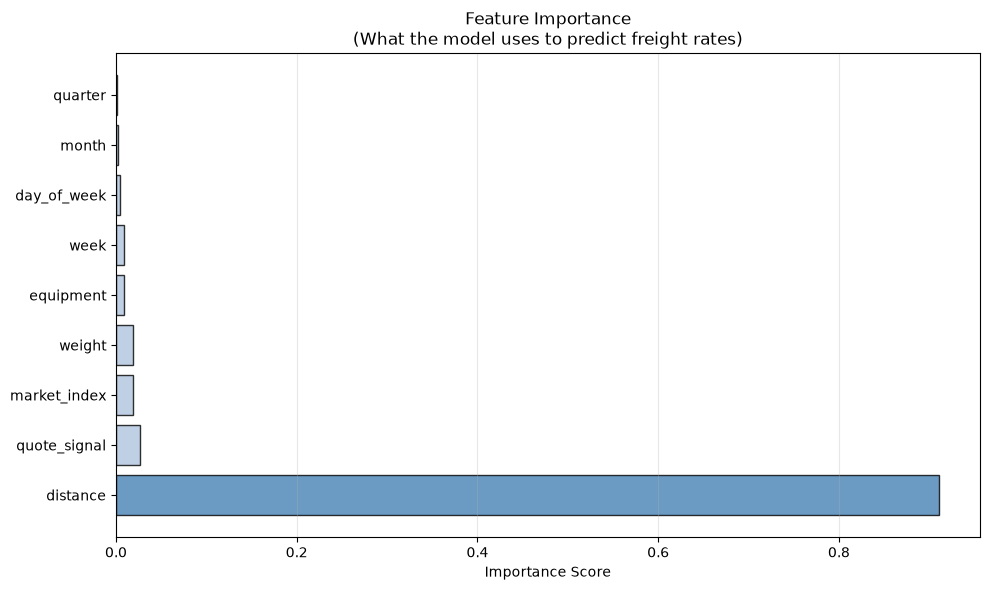

Saved: feature_importance.png


In [77]:
#Feature Importance

feature_importance = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\n  {'Feature':<20} {'Importance':>10}  Bar")
print(f"  {'-'*55}")
for _, row in feature_importance.iterrows():
    bar = "█" * int(row['Importance'] * 50)
    print(f"  {row['Feature']:<20} {row['Importance']:>10.4f}  {bar}")

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
colors  = ['steelblue' if i == 0 else 'lightsteelblue'
           for i in range(len(feature_importance))]
ax.barh(feature_importance['Feature'],
        feature_importance['Importance'],
        color=colors, edgecolor='black', alpha=0.8)
ax.set_xlabel('Importance Score')
ax.set_title('Feature Importance\n(What the model uses to predict freight rates)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=110)
plt.show()
print("Saved: feature_importance.png")

In [78]:
#Hold out vs. Training score

print(f"""
  Train MAE: ${mae_train:.2f}  ← Model already knows these answers 
  Test MAE:  ${mae_test:.2f}  ← Model never saw this data 
  Gap:       ${mae_test - mae_train:.2f}  ← This is called overfitting

  Always report: Test MAE = ${mae_test:.2f}
  Never report:  Train MAE = ${mae_train:.2f}  (misleading)
""")



  Train MAE: $77.54  ← Model already knows these answers 
  Test MAE:  $123.84  ← Model never saw this data 
  Gap:       $46.30  ← This is called overfitting

  Always report: Test MAE = $123.84
  Never report:  Train MAE = $77.54  (misleading)



In [79]:
# Refit on all Development Data

# Once validated, retrain on ALL labeled data for best production performance
X_full = X.copy()
y_full = y.copy()

# Refit imputer and encoder on full dataset
imputer_final = SimpleImputer(strategy='median')
X_full[IMPUTE_COLS] = imputer_final.fit_transform(X_full[IMPUTE_COLS])

le_final = LabelEncoder()
X_full['equipment'] = le_final.fit_transform(X_full['equipment'])

# Refit model on full dataset
model_final = RandomForestRegressor(
    n_estimators=300,
    max_depth=18,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

print(f"Refitting on all {len(X_full):,} rows...")
model_final.fit(X_full, y_full)
print(f"Final model trained on full development data")
print(f"\nWhy refit on all data?")
print(f"  We already validated performance on the test set")
print(f"  Using all {len(X_full):,} rows gives model more to learn from")
print(f"  Makes predictions on production data more accurate")

Refitting on all 48,000 rows...
Final model trained on full development data

Why refit on all data?
  We already validated performance on the test set
  Using all 48,000 rows gives model more to learn from
  Makes predictions on production data more accurate


In [80]:
#Prepare Production Data

X_prod = df_prod[FEATURES].copy()

print(f"  Production rows:              {len(X_prod):,}")
print(f"  Missing before imputation:    {X_prod.isnull().sum().sum()}")
print(f"  Equipment values:             {X_prod['equipment'].unique().tolist()}")

# Apply SAME preprocessors — transform only, NEVER fit again!
X_prod[IMPUTE_COLS]  = imputer_final.transform(X_prod[IMPUTE_COLS])
X_prod['equipment']  = le_final.transform(X_prod['equipment'])

# Verify
assert X_prod.isnull().sum().sum() == 0, "Missing values remain!"
assert len(X_prod) == 12000, "Row count changed — all 12,000 loads required!"
print(f"  Missing after imputation:     0")
print(f"\n All {len(X_prod):,} production rows ready")

  Production rows:              12,000
  Missing before imputation:    414
  Equipment values:             ['Flatbed', 'Reefer', 'Dry Van']
  Missing after imputation:     0

 All 12,000 production rows ready


 Generated 12,000 predictions

  Prediction statistics:
    Count:  12,000
    Min:    $171.33
    Max:    $9391.47
    Mean:   $2465.09
    Median: $2079.07
    Std:    $1503.89

  Sanity check (should be similar to training):
    Train mean:   $2373.98  |  Pred mean:   $2465.09
    Train median: $2030.76  |  Pred median: $2079.07


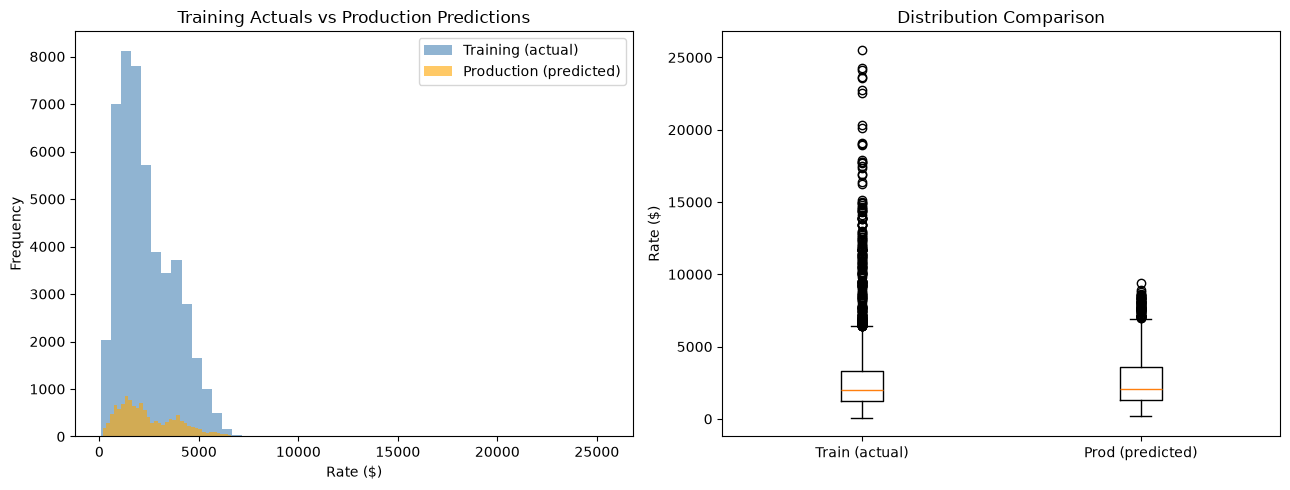

 Saved: prediction_distribution.png


In [81]:
# Predict on Production Data

y_prod_pred = model_final.predict(X_prod)

print(f" Generated {len(y_prod_pred):,} predictions")
print(f"\n  Prediction statistics:")
print(f"    Count:  {len(y_prod_pred):,}")
print(f"    Min:    ${y_prod_pred.min():.2f}")
print(f"    Max:    ${y_prod_pred.max():.2f}")
print(f"    Mean:   ${y_prod_pred.mean():.2f}")
print(f"    Median: ${np.median(y_prod_pred):.2f}")
print(f"    Std:    ${y_prod_pred.std():.2f}")

# Sanity check: compare to training distribution
print(f"\n  Sanity check (should be similar to training):")
print(f"    Train mean:   ${y_full.mean():.2f}  |  Pred mean:   ${y_prod_pred.mean():.2f}")
print(f"    Train median: ${y_full.median():.2f}  |  Pred median: ${np.median(y_prod_pred):.2f}")

# Visualize prediction distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(y_full, bins=50, alpha=0.6,
             label='Training (actual)', color='steelblue')
axes[0].hist(y_prod_pred, bins=50, alpha=0.6,
             label='Production (predicted)', color='orange')
axes[0].set_xlabel('Rate ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Training Actuals vs Production Predictions')
axes[0].legend()

axes[1].boxplot([y_full, y_prod_pred],
                tick_labels=['Train (actual)', 'Prod (predicted)'])
axes[1].set_ylabel('Rate ($)')
axes[1].set_title('Distribution Comparison')

plt.tight_layout()
plt.savefig('prediction_distribution.png', dpi=110)
plt.show()
print(" Saved: prediction_distribution.png")

In [82]:
# Map predictions to load_ids explicitly (safer than relying on row order)

pred_map = dict(zip(df_prod['load_id'], y_prod_pred))
output   = template.copy()
output['predicted_rate'] = output['load_id'].map(pred_map).round(2)

# Final quality checks
assert output['predicted_rate'].isnull().sum() == 0, "Missing predictions!"
assert len(output) == 12000,                         "Row count mismatch!"
assert output['load_id'].duplicated().sum() == 0,    "Duplicate load_ids!"
assert (output['predicted_rate'] < 0).sum() == 0,   "Negative predictions!"

output.to_csv('validation_predictions.csv', index=False)

print(f" Saved: validation_predictions.csv")
print(f"\n  Quality checks:")
print(f"    Total rows:           {len(output):,} / 12,000")
print(f"    Missing predictions:  {output['predicted_rate'].isnull().sum()}")
print(f"    Duplicate load_ids:   {output['load_id'].duplicated().sum()}")
print(f"    Negative rates:       {(output['predicted_rate'] < 0).sum()}")
print(f"\n  Preview (first 10 rows):")
print(output.head(10).to_string(index=False))

 Saved: validation_predictions.csv

  Quality checks:
    Total rows:           12,000 / 12,000
    Missing predictions:  0
    Duplicate load_ids:   0
    Negative rates:       0

  Preview (first 10 rows):
  load_id  predicted_rate
TE-000001          841.72
TE-000002         4942.86
TE-000003         5951.47
TE-000004         4406.35
TE-000005         1774.35
TE-000006         4485.18
TE-000007         5214.05
TE-000008         2839.96
TE-000009         1071.37
TE-000010         1278.05


In [83]:
#Save Model for future use

# Save with joblib (required for sklearn objects — do NOT use pickle!)
joblib.dump(model_final,   'freight_rate_model.pkl')
joblib.dump(imputer_final, 'imputer.pkl')
joblib.dump(le_final,      'equipment_encoder.pkl')

# Save feature list for documentation
with open('feature_columns.txt', 'w') as f:
    f.write('\n'.join(FEATURES))

print(f" freight_rate_model.pkl    — final trained Random Forest")
print(f" imputer.pkl               — fitted median imputer")
print(f" equipment_encoder.pkl     — fitted label encoder")
print(f" feature_columns.txt       — list of features used")
print(f"\nTo reload later:")
print(f"  import joblib")
print(f"  model   = joblib.load('freight_rate_model.pkl')")
print(f"  imputer = joblib.load('imputer.pkl')")
print(f"  encoder = joblib.load('equipment_encoder.pkl')")

 freight_rate_model.pkl    — final trained Random Forest
 imputer.pkl               — fitted median imputer
 equipment_encoder.pkl     — fitted label encoder
 feature_columns.txt       — list of features used

To reload later:
  import joblib
  model   = joblib.load('freight_rate_model.pkl')
  imputer = joblib.load('imputer.pkl')
  encoder = joblib.load('equipment_encoder.pkl')


In [84]:
print(f"""
  ┌─────────────────────────────────────────────────────────────────┐
  │              FREIGHT RATE PREDICTION — SUMMARY                  │
  ├─────────────────────────────────────────────────────────────────┤
  │ DATA                                                            │
  │   Development rows:       {len(df):,}                                │
  │   Train set (80%):        {len(X_train):,} rows                           │
  │   Test set  (20%):        {len(X_test):,} rows                            │
  │   Production set:         12,000 rows                           │
  ├─────────────────────────────────────────────────────────────────┤
  │ DATA CLEANING                                                   │
  │   Weight sign-flips:      Fixed with .abs()                     │
  │   Missing values:         Median imputation (not dropping)      │
  │   Duplicate rows:         0 found                               │
  ├─────────────────────────────────────────────────────────────────┤
  │ FEATURES ({len(FEATURES)} selected)                                           │
  │   distance, weight, market_index, quote_signal, equipment,      │
  │   month, week, day_of_week, quarter                             │
  ├─────────────────────────────────────────────────────────────────┤
  │ MODEL                                                           │
  │   Type:                   RandomForestRegressor                 │
  │   Trees:                  300                                   │
  │   Max depth:              18                                    │
  │   Min samples leaf:       2                                     │
  │   Winner over:            Linear Regression                     │
  ├─────────────────────────────────────────────────────────────────┤
  │ TEST SET PERFORMANCE (real metrics)                             │
  │   MAE:                    ${mae_test:.2f}                               │
  │   RMSE:                   ${rmse_test:.2f}                               │
  │   R²:                     {r2_test:.4f}                                │
  │   MAPE:                   {mape_test:.2f}%                                 │
  ├─────────────────────────────────────────────────────────────────┤
  │ OUTPUT                                                          │
  │   File:                   validation_predictions.csv            │
  │   Total predictions:      12,000 / 12,000                       |
  │   Missing predictions:    0                                     |                         
  └─────────────────────────────────────────────────────────────────┘
""")



  ┌─────────────────────────────────────────────────────────────────┐
  │              FREIGHT RATE PREDICTION — SUMMARY                  │
  ├─────────────────────────────────────────────────────────────────┤
  │ DATA                                                            │
  │   Development rows:       48,000                                │
  │   Train set (80%):        38,400 rows                           │
  │   Test set  (20%):        9,600 rows                            │
  │   Production set:         12,000 rows                           │
  ├─────────────────────────────────────────────────────────────────┤
  │ DATA CLEANING                                                   │
  │   Weight sign-flips:      Fixed with .abs()                     │
  │   Missing values:         Median imputation (not dropping)      │
  │   Duplicate rows:         0 found                               │
  ├─────────────────────────────────────────────────────────────────┤
  │ FEATURES (9 sel